# AGU manuscript figure exports

This notebook regenerates every result PDF requested by `agujournaltemplate.tex`. Figure 1 (the apparatus sketch) is an existing external drawing; Figures 2--6 are generated here from the ranked ORCA result CSV files and the digitized Ye & Ghassemi (2018) Table 2 data.

The output is vector PDF with embedded TrueType fonts. Loading and unloading remain ordered as stages 1--11: `8, 12, 16, 20, 24, 28, 24, 20, 16, 12, 8 MPa`. Hydraulic aperture is shown only as an informational quantity derived from flow and is not scored independently.

## 1. Paths and selected cases

Edit only this block when a final case or paper location changes. The path finder permits the notebook to be launched from the project root or any child directory. Set `RESULTS_DIR` below to the folder that should receive the exported PDFs.

In [4]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

def find_project_root(start=Path.cwd().resolve()):
    for candidate in (start, *start.parents):
        if ((candidate / 'scripts' / 'table2_gate.py').is_file()
                and (candidate / 'Examples' / 'YeGhasemmi2018').is_dir()):
            return candidate
    fallback = Path('/media/geomechanics/Data4TB/projects/orca_4.0')
    if (fallback / 'scripts' / 'table2_gate.py').is_file():
        return fallback
    raise FileNotFoundError('Could not locate the ORCA project root')

PROJECT_ROOT = find_project_root()

# Folder for the exported manuscript PDFs.
# Use an absolute path, or a path relative to PROJECT_ROOT.
RESULTS_DIR = Path('Examples/YeGhasemmi2018/Docs/figures')
OUTPUT_DIR = RESULTS_DIR if RESULTS_DIR.is_absolute() else PROJECT_ROOT / RESULTS_DIR
OUTPUT_DIR = OUTPUT_DIR.expanduser().resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEPENDENCY_DIR = PROJECT_ROOT / 'scripts'
if str(DEPENDENCY_DIR) not in sys.path:
    sys.path.insert(0, str(DEPENDENCY_DIR))
import table2_gate as gate

from types import SimpleNamespace
# The plotting backend is intentionally kept in this notebook.
import string
from cycler import cycler
from matplotlib import font_manager
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import MaxNLocator
from matplotlib.text import Text
import numpy as np
RANKING_PATH = (
    PROJECT_ROOT
    / "Examples"
    / "YeGhasemmi2018"
    / "Docs"
    / "Memory"
    / "TABLE2_ERROR_ACCURACY_RANKING.csv"
)

SAMPLE_ORDER = ("SWT1", "SWT2", "SWS3", "SWS4")
DISPLAY_NAME = {
    "SWT1": "SW-T1",
    "SWT2": "SW-T2",
    "SWS3": "SW-S3",
    "SWS4": "SW-S4",
}

# Authoritative final selections after the 2026-08-27 equal-budget MC sweep.
FINAL_BB_CASES = {
    "SWT1": "107_01_swt1_coh27p2_apscale0p01512_ppfix",
    "SWT2": "100_04_swt2_apscale0p0177_ppfix",
    "SWS3": "100_06_sw3_resc1p30_unld0p00_ppfix",
    "SWS4": "93_07_sw4_final_theta30_jrc5_ppfix",
}

FINAL_MC_CASES = {
    "SWT1": "SWT1_OrcaMohrCoulombContactTraction_pb04",
    "SWT2": "SWT2_OrcaMohrCoulombContactTraction_pb04",
    "SWS3": "SWS3_OrcaMohrCoulombContactTraction_pb06",
    "SWS4": "SWS4_OrcaMohrCoulombContactTraction_center",
}

FINAL_MC_RESULT_PATHS = {
    sample: (
        PROJECT_ROOT / "Examples" / "YeGhasemmi2018" / sample
        / "results_csv_mc_sweep_hpc" / f"{case}.csv"
    )
    for sample, case in FINAL_MC_CASES.items()
}

MESH_CASES = {
    "SWT1": (
        "93_01_swt1_final_c26p9_resc9p19_ppfix",
        "93_02_swt1_final_c26p9_resc9p19_ppfix_mesh3",
    ),
    "SWT2": (
        "93_03_swt2_final_theta30_resc9p71_ppfix",
        "93_04_swt2_final_theta30_resc9p71_ppfix_mesh3",
    ),
    "SWS3": (
        "93_05_sw3_final_resc1p40_ppfix",
        "93_06_sw3_final_resc1p40_ppfix_mesh3",
    ),
    "SWS4": (
        "93_07_sw4_final_theta30_jrc5_ppfix",
        "93_08_sw4_final_theta30_jrc5_ppfix_mesh3",
    ),
}

# parent BBFast, exponent-1 BBFast control, matched 102-series MC transfer
WEAKENING_CASES = {
    "SWT1": (
        "100_01_swt1_vm55um_ppfix",
        "103_01_swt1_weakexp1p0_ppfix",
        "102_01_swt1_mc_vm55um_ppfix",
    ),
    "SWT2": (
        "100_04_swt2_apscale0p0177_ppfix",
        "103_02_swt2_weakexp1p0_ppfix",
        "102_02_swt2_mc_apscale0p0177_ppfix",
    ),
    "SWS3": (
        "100_06_sw3_resc1p30_unld0p00_ppfix",
        "103_03_sw3_weakexp1p0_ppfix",
        "102_03_sw3_mc_resc1p30_ppfix",
    ),
}

FIGURE_FILENAMES = {
    "mesh_sensitivity": "Figure_2_Mesh_Sensitivity.pdf",
    "validation_histories": "Figure_3_Validation_Histories.pdf",
    "hydraulic_response": "Figure_4_Hydraulic_Response.pdf",
    "bb_mc_comparison": "Figure_5_BBFast_vs_MC.pdf",
    "weakening_control": "Figure_6_Weakening_Controls.pdf",
}

PRESSURES = np.asarray(gate.PI_TARGETS, dtype=float)
STAGES = np.arange(1, len(PRESSURES) + 1)

BLACK = "#202020"
GRAY = "#767676"
BLUE = "#0072B2"
ORANGE = "#D55E00"
GREEN = "#009E73"
PURPLE = "#8B55E8"
YELLOW = "#F0E442"

# ---------------------------------------------------------------------------
# Reproducible figure-production controls.  Keep these in one place so the
# notebook previews and the exported manuscript PDFs cannot silently diverge.
# ---------------------------------------------------------------------------
TIMES_FONT_CANDIDATES = (
    "Times New Roman",  # Windows/macOS when installed
    "Times",
    "Nimbus Roman",     # Times-compatible font available on this Linux host
    "TeX Gyre Termes",
    "DejaVu Serif",     # portable last resort
)


def _first_available_font(candidates: tuple[str, ...]) -> str:
    for name in candidates:
        try:
            font_manager.findfont(name, fallback_to_default=False)
        except (ValueError, RuntimeError):
            continue
        return name
    raise RuntimeError("No Times-compatible serif font is installed")


AGU_FONT_NAME = _first_available_font(TIMES_FONT_CANDIDATES)
AGU_FIGURE_DPI = 150
AGU_SAVE_DPI = 300
AGU_TEXT_SIZES_PT = {
    "base": 7.0,
    "title": 7.4,
    "axis_label": 6.9,
    "tick": 6.0,
    "legend": 6.5,
}
AGU_MAX_TEXT_SIZE_PT = 8.5
AGU_COLOR_CYCLE = (BLUE, ORANGE, GREEN, PURPLE, BLACK, GRAY)
FIGURE_SIZES_IN = {
    "mesh_sensitivity": (3.45, 2.75),
    "validation_histories": (7.2, 7.75),
    "hydraulic_response": (7.2, 7.5),
    "bb_mc_comparison": (7.2, 8.45),
    "weakening_control": (7.2, 2.8),
}


def apply_agu_style() -> None:
    """Apply the single controlled style used by every AGU manuscript figure."""
    plt.rcParams.update(
        {
            "font.family": AGU_FONT_NAME,
            "font.size": AGU_TEXT_SIZES_PT["base"],
            "axes.titlesize": AGU_TEXT_SIZES_PT["title"],
            "axes.labelsize": AGU_TEXT_SIZES_PT["axis_label"],
            "xtick.labelsize": AGU_TEXT_SIZES_PT["tick"],
            "ytick.labelsize": AGU_TEXT_SIZES_PT["tick"],
            "legend.fontsize": AGU_TEXT_SIZES_PT["legend"],
            "mathtext.fontset": "stix",
            "figure.dpi": AGU_FIGURE_DPI,
            "savefig.dpi": AGU_SAVE_DPI,
            "axes.prop_cycle": cycler(color=AGU_COLOR_CYCLE),
            "axes.linewidth": 0.65,
            "lines.linewidth": 1.15,
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
            "figure.facecolor": "white",
            "savefig.facecolor": "white",
        }
    )


def validate_agu_style() -> dict[str, object]:
    """Check the global figure controls before any manuscript figure is saved."""
    checks = {
        "font": plt.rcParams["font.family"] == [AGU_FONT_NAME],
        "math_font": plt.rcParams["mathtext.fontset"] == "stix",
        "figure_dpi": int(round(float(plt.rcParams["figure.dpi"]))) == AGU_FIGURE_DPI,
        "save_dpi": int(round(float(plt.rcParams["savefig.dpi"]))) == AGU_SAVE_DPI,
        "color_cycle": tuple(plt.rcParams["axes.prop_cycle"].by_key()["color"]) == AGU_COLOR_CYCLE,
        "legend_size": float(plt.rcParams["legend.fontsize"]) == AGU_TEXT_SIZES_PT["legend"],
        "pdf_true_type": plt.rcParams["pdf.fonttype"] == 42,
    }
    failed = [name for name, passed in checks.items() if not passed]
    if failed:
        raise AssertionError(f"AGU figure style check failed: {', '.join(failed)}")
    return checks


def validate_figure(figure_key: str, figure: plt.Figure) -> dict[str, object]:
    """Validate one figure's size, DPI, text sizes, and legends before export."""
    validate_agu_style()
    if figure_key not in FIGURE_SIZES_IN:
        raise KeyError(f"Unknown AGU figure key: {figure_key}")
    expected = np.asarray(FIGURE_SIZES_IN[figure_key], dtype=float)
    actual = np.asarray(figure.get_size_inches(), dtype=float)
    if not np.allclose(actual, expected, rtol=0.0, atol=1e-6):
        raise AssertionError(
            f"{figure_key}: expected {tuple(expected)} inches, got {tuple(actual)}"
        )
    if int(round(float(figure.dpi))) != AGU_FIGURE_DPI:
        raise AssertionError(f"{figure_key}: expected figure DPI {AGU_FIGURE_DPI}, got {figure.dpi}")

    texts = figure.findobj(Text)
    oversized = [text.get_text() for text in texts if text.get_fontsize() > AGU_MAX_TEXT_SIZE_PT]
    if oversized:
        raise AssertionError(
            f"{figure_key}: text exceeds {AGU_MAX_TEXT_SIZE_PT} pt: {oversized[:3]}"
        )
    legends = list(figure.legends)
    legends.extend(legend for ax in figure.axes
                   if (legend := ax.get_legend()) is not None)
    legend_texts = [text for legend in legends for text in legend.get_texts()]
    oversized_legends = [text.get_text() for text in legend_texts
                         if text.get_fontsize() > AGU_TEXT_SIZES_PT["legend"] + 1e-9]
    if oversized_legends:
        raise AssertionError(
            f"{figure_key}: legend text exceeds {AGU_TEXT_SIZES_PT['legend']} pt: "
            f"{oversized_legends[:3]}"
        )
    return {
        "figure_key": figure_key,
        "width_in": float(actual[0]),
        "height_in": float(actual[1]),
        "figure_dpi": int(round(float(figure.dpi))),
        "save_dpi": AGU_SAVE_DPI,
        "font": AGU_FONT_NAME,
        "text_max_pt": max((text.get_fontsize() for text in texts), default=0.0),
        "legend_count": len(legends),
    }


def _ranking() -> pd.DataFrame:
    if not RANKING_PATH.is_file():
        raise FileNotFoundError(RANKING_PATH)
    return pd.read_csv(RANKING_PATH)


def result_path(sample: str, row: pd.Series) -> Path:
    """Resolve a ranked result after campaign folders have been reorganized."""
    recorded = PROJECT_ROOT / str(row["source_csv"])
    if recorded.is_file():
        return recorded
    sample_root = PROJECT_ROOT / "Examples" / "YeGhasemmi2018" / sample
    candidates = [
        path
        for path in sample_root.rglob(recorded.name)
        if "partial_every_step" not in path.parts
    ]
    if not candidates:
        raise FileNotFoundError(recorded)
    # SWT1 currently contains equivalent Sweeps/sweeeep archival copies.  Use
    # the canonical capitalized directory deterministically when both exist.
    candidates.sort(
        key=lambda path: (
            0 if "Sweeps" in path.parts else 1,
            len(path.parts),
            str(path),
        )
    )
    return candidates[0]


def resolve_case(
    sample: str,
    case: str,
    ranking: pd.DataFrame | None = None,
    verify_result: bool = True,
) -> pd.Series:
    """Resolve one named case and verify that its result CSV exists."""
    ranking = _ranking() if ranking is None else ranking
    rows = ranking.loc[ranking["sample"].eq(sample) & ranking["case"].eq(case)]
    if rows.empty and FINAL_MC_CASES.get(sample) == case:
        path = FINAL_MC_RESULT_PATHS[sample]
        if verify_result and not path.is_file():
            raise FileNotFoundError(path)
        scored = gate.score_run(
            csv_path=path,
            sample=sample,
            tag=case.rsplit("_", 1)[-1],
            tol_mpa=0.15,
            datum="stage1",
            preload_time=55.0,
            dn_channel="kinematic",
        )
        normalised = gate.normalised_scores(scored)
        return pd.Series(
            {
                "sample": sample,
                "case": case,
                "mean_nrmse_pct": normalised["mean"],
                "stages_reached": scored["reached"],
                "source_csv": str(path.relative_to(PROJECT_ROOT)),
            }
        )
    if len(rows) != 1:
        raise ValueError(f"{sample}: expected exactly one row for {case!r}; found {len(rows)}")
    row = rows.iloc[0]
    if verify_result:
        result_path(sample, row)
    return row


def score_case(sample: str, case: str, ranking: pd.DataFrame | None = None) -> dict:
    """Extract and score all eleven ordered Table 2 stages for one result."""
    row = resolve_case(sample, case, ranking)
    tag = case.rsplit("_", 1)[-1] if FINAL_MC_CASES.get(sample) == case else "hpc"
    result = gate.score_run(
        csv_path=result_path(sample, row),
        sample=sample,
        tag=tag,
        tol_mpa=0.15,
        datum="stage1",
        preload_time=55.0,
        dn_channel="kinematic",
    )
    if int(result["reached"]) != 11:
        raise ValueError(f"{sample} / {case}: reached {result['reached']}/11 stages")
    return result


def preflight(
    bb_cases: dict[str, str] = FINAL_BB_CASES,
    mc_cases: dict[str, str] = FINAL_MC_CASES,
) -> pd.DataFrame:
    """Return the selected-case inventory; raise early on missing files/cases."""
    ranking = _ranking()
    rows: list[dict] = []
    for model, mapping in (("BBFast", bb_cases), ("Mohr-Coulomb", mc_cases)):
        for sample in SAMPLE_ORDER:
            row = resolve_case(sample, mapping[sample], ranking)
            rows.append(
                {
                    "model": model,
                    "sample": DISPLAY_NAME[sample],
                    "case": row["case"],
                    "mean_nRMSE_pct": float(row["mean_nrmse_pct"]),
                    "stages": f"{int(row['stages_reached'])}/11",
                    "result_csv": str(result_path(sample, row).relative_to(PROJECT_ROOT)),
                }
            )
    return pd.DataFrame(rows)


def _score_map(case_map: dict[str, str]) -> dict[str, dict]:
    ranking = _ranking()
    return {sample: score_case(sample, case_map[sample], ranking) for sample in SAMPLE_ORDER}


def _panel_style(ax: plt.Axes, letter: str | None = None) -> None:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="out", length=2.5, width=0.6, pad=1.4)
    ax.grid(axis="y", color="#D9D9D9", linewidth=0.35, alpha=0.7)
    if letter is not None:
        ax.text(
            0.02,
            0.96,
            f"({letter})",
            transform=ax.transAxes,
            va="top",
            ha="left",
            fontsize=6.6,
            fontweight="bold",
            bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.82, "pad": 0.4},
            zorder=10,
        )


def _stage_axis(ax: plt.Axes, show_labels: bool = True, stage5: bool = False) -> None:
    ax.set_xlim(0.6, 11.4)
    ax.set_xticks(STAGES)
    if show_labels:
        ax.set_xticklabels([f"{int(p)}" for p in PRESSURES])
        ax.set_xlabel("Ordered stage (injection pressure, MPa)")
    else:
        ax.tick_params(axis="x", labelbottom=False)
    ax.axvline(6.5, color="#A0A0A0", linewidth=0.55, linestyle=":", zorder=0)
    ax.axvspan(6.5, 11.4, color="#F1F1F1", alpha=0.40, zorder=-5)
    if stage5:
        ax.axvspan(4.72, 5.28, color=YELLOW, alpha=0.22, zorder=-4)


def _limits(*arrays: np.ndarray, pad: float = 0.08) -> tuple[float, float]:
    values = np.concatenate([np.asarray(a, dtype=float).ravel() for a in arrays])
    values = values[np.isfinite(values)]
    if values.size == 0:
        return 0.0, 1.0
    low, high = float(values.min()), float(values.max())
    span = high - low
    if span == 0.0:
        span = max(abs(high), 1.0) * 0.1
    return low - pad * span, high + pad * span


def _model_and_paper(result: dict, key: str) -> tuple[np.ndarray, np.ndarray]:
    table = result["table"]
    return (
        pd.to_numeric(table[f"{key}_model"], errors="coerce").to_numpy(float),
        pd.to_numeric(table[f"{key}_paper"], errors="coerce").to_numpy(float),
    )


def figure_mesh_sensitivity(
    mesh_cases: dict[str, tuple[str, str]] = MESH_CASES,
) -> plt.Figure:
    """Figure 2: production/refined dumbbell comparison of mean nRMSE."""
    apply_agu_style()
    ranking = _ranking()
    production = []
    refined = []
    for sample in SAMPLE_ORDER:
        coarse_case, fine_case = mesh_cases[sample]
        production.append(
            float(resolve_case(sample, coarse_case, ranking, verify_result=False)["mean_nrmse_pct"])
        )
        refined.append(
            float(resolve_case(sample, fine_case, ranking, verify_result=False)["mean_nrmse_pct"])
        )

    production = np.asarray(production)
    refined = np.asarray(refined)
    y = np.arange(len(SAMPLE_ORDER))[::-1]
    figure, ax = plt.subplots(figsize=FIGURE_SIZES_IN["mesh_sensitivity"])
    for yi, coarse, fine in zip(y, production, refined):
        ax.plot([coarse, fine], [yi, yi], color="#A8A8A8", linewidth=1.3, zorder=1)
        ax.text(
            max(coarse, fine) + 0.10,
            yi,
            f"$\\Delta$ {fine - coarse:+.3f}",
            va="center",
            ha="left",
            fontsize=6.3,
        )
    ax.scatter(production, y, s=25, color=BLUE, marker="o", zorder=3, label="Production mesh (factor 5)")
    ax.scatter(refined, y, s=28, facecolor="white", edgecolor=ORANGE, linewidth=1.0, marker="s", zorder=4, label="Refined mesh (factor 3)")
    ax.set_yticks(y, [DISPLAY_NAME[s] for s in SAMPLE_ORDER])
    ax.set_xlabel("Five-channel mean nRMSE (%)")
    ax.set_xlim(1.7, 6.9)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
    _panel_style(ax)
    ax.legend(frameon=False, loc="lower center", bbox_to_anchor=(0.5, 1.01), ncol=1)
    figure.tight_layout(pad=0.6)
    validate_figure("mesh_sensitivity", figure)
    return figure


VALIDATION_SPECS = (
    ("Q_ml_min", "Flow rate\n(mL min$^{-1}$)"),
    ("sigma_n_MPa", "Effective normal stress\n(MPa)"),
    ("tau_MPa", "Shear stress\n(MPa)"),
    ("dn_mm", "Normal displacement\n(mm)"),
    ("ds_mm", "Shear displacement\n(mm)"),
)


def figure_validation_histories(
    bb_cases: dict[str, str] = FINAL_BB_CASES,
) -> plt.Figure:
    """Figure 3: five measured/modelled channels for all final BBFast cases."""
    apply_agu_style()
    scored = _score_map(bb_cases)
    figure, axes = plt.subplots(4, 5, figsize=FIGURE_SIZES_IN["validation_histories"], squeeze=False)
    letters = iter(string.ascii_lowercase)
    for row_index, sample in enumerate(SAMPLE_ORDER):
        for column_index, (key, title) in enumerate(VALIDATION_SPECS):
            ax = axes[row_index, column_index]
            model, paper = _model_and_paper(scored[sample], key)
            ax.plot(STAGES, model, color=BLUE, linewidth=1.2, zorder=2)
            ax.plot(
                STAGES,
                paper,
                linestyle="none",
                marker="o",
                markersize=3.0,
                markerfacecolor="white",
                markeredgecolor=BLACK,
                markeredgewidth=0.75,
                zorder=4,
            )
            ax.set_ylim(*_limits(model, paper))
            ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
            _stage_axis(ax, show_labels=False)
            if row_index == 3:
                ax.tick_params(axis="x", labelbottom=True)
                ax.set_xticklabels([f"{int(p)}" for p in PRESSURES])
            _panel_style(ax, next(letters))
            if row_index == 0:
                ax.set_title(title, pad=5.0, fontweight="bold")

    figure.subplots_adjust(left=0.09, right=0.995, bottom=0.08, top=0.90, wspace=0.42, hspace=0.30)
    for row_index, sample in enumerate(SAMPLE_ORDER):
        pos = axes[row_index, 0].get_position()
        figure.text(0.015, (pos.y0 + pos.y1) / 2, DISPLAY_NAME[sample], rotation=90, va="center", ha="center", fontweight="bold")
    figure.legend(
        handles=(
            Line2D([], [], color=BLACK, linestyle="none", marker="o", markerfacecolor="white", markersize=3.3, label="Ye & Ghassemi (2018), Table 2"),
            Line2D([], [], color=BLUE, linewidth=1.25, label="Selected BBFast simulation"),
            Patch(facecolor="#F1F1F1", edgecolor="none", label="Unloading stages"),
        ),
        loc="upper center",
        bbox_to_anchor=(0.53, 0.985),
        frameon=False,
        ncol=3,
    )
    figure.supxlabel("Ordered stage (injection pressure, MPa)", y=0.022, fontsize=6.9)
    validate_figure("validation_histories", figure)
    return figure


HYDRAULIC_SPECS = (
    ("dn_mm", "Normal displacement\n(mm)"),
    ("ah_um", "Hydraulic aperture\n($\\mu$m)"),
    ("Q_ml_min", "Validation-equivalent flow\n(mL min$^{-1}$)"),
)


def figure_hydraulic_response(
    bb_cases: dict[str, str] = FINAL_BB_CASES,
) -> plt.Figure:
    """Figure 4: coupled normal displacement, aperture, and flow response."""
    apply_agu_style()
    scored = _score_map(bb_cases)
    figure, axes = plt.subplots(4, 3, figsize=FIGURE_SIZES_IN["hydraulic_response"], squeeze=False)
    letters = iter(string.ascii_lowercase)
    for row_index, sample in enumerate(SAMPLE_ORDER):
        for column_index, (key, title) in enumerate(HYDRAULIC_SPECS):
            ax = axes[row_index, column_index]
            model, paper = _model_and_paper(scored[sample], key)
            ax.plot(STAGES, model, color=BLUE, linewidth=1.25, zorder=2)
            marker = "D" if key == "ah_um" else "o"
            edge = GRAY if key == "ah_um" else BLACK
            ax.plot(
                STAGES,
                paper,
                linestyle="none",
                marker=marker,
                markersize=3.0,
                markerfacecolor="white",
                markeredgecolor=edge,
                markeredgewidth=0.75,
                zorder=4,
            )
            ax.set_ylim(*_limits(model, paper))
            ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
            _stage_axis(ax, show_labels=False)
            if row_index == 3:
                ax.tick_params(axis="x", labelbottom=True)
                ax.set_xticklabels([f"{int(p)}" for p in PRESSURES])
            _panel_style(ax, next(letters))
            if row_index == 0:
                ax.set_title(title, pad=5.0, fontweight="bold")

    figure.subplots_adjust(left=0.09, right=0.995, bottom=0.08, top=0.89, wspace=0.30, hspace=0.30)
    for row_index, sample in enumerate(SAMPLE_ORDER):
        pos = axes[row_index, 0].get_position()
        figure.text(0.015, (pos.y0 + pos.y1) / 2, DISPLAY_NAME[sample], rotation=90, va="center", ha="center", fontweight="bold")
    figure.legend(
        handles=(
            Line2D([], [], color=BLUE, linewidth=1.25, label="Selected BBFast simulation"),
            Line2D([], [], color=BLACK, linestyle="none", marker="o", markerfacecolor="white", markersize=3.3, label="Measured $d_n$ or $Q$"),
            Line2D([], [], color=GRAY, linestyle="none", marker="D", markerfacecolor="white", markersize=3.2, label="Table 2 $a_h$ (derived from $Q$; informational)"),
        ),
        loc="upper center",
        bbox_to_anchor=(0.53, 0.985),
        frameon=False,
        ncol=3,
    )
    figure.supxlabel("Ordered stage (injection pressure, MPa)", y=0.022, fontsize=6.9)
    validate_figure("hydraulic_response", figure)
    return figure


def figure_bb_mc_comparison(
    bb_cases: dict[str, str] = FINAL_BB_CASES,
    mc_cases: dict[str, str] = FINAL_MC_CASES,
) -> plt.Figure:
    """Figure 5: mechanical histories plus paired mean-error summary."""
    apply_agu_style()
    bb = _score_map(bb_cases)
    mc = _score_map(mc_cases)
    ranking = _ranking()
    figure = plt.figure(figsize=FIGURE_SIZES_IN["bb_mc_comparison"])
    grid = figure.add_gridspec(5, 2, height_ratios=(1, 1, 1, 1, 1.0), hspace=0.40, wspace=0.25)
    letters = iter(string.ascii_lowercase)
    axes: list[list[plt.Axes]] = []
    for row_index, sample in enumerate(SAMPLE_ORDER):
        row_axes = []
        for column_index, (key, title) in enumerate((("tau_MPa", "Shear stress (MPa)"), ("ds_mm", "Shear displacement (mm)"))):
            ax = figure.add_subplot(grid[row_index, column_index])
            bb_model, paper = _model_and_paper(bb[sample], key)
            mc_model, _ = _model_and_paper(mc[sample], key)
            ax.plot(STAGES, bb_model, color=BLUE, zorder=3)
            ax.plot(STAGES, mc_model, color=ORANGE, linestyle="--", zorder=2)
            ax.plot(STAGES, paper, color=BLACK, linestyle="none", marker="o", markersize=3.0, markerfacecolor="white", markeredgewidth=0.75, zorder=4)
            ax.set_ylim(*_limits(bb_model, mc_model, paper))
            ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
            _stage_axis(ax, show_labels=row_index == 3, stage5=True)
            _panel_style(ax, next(letters))
            if row_index == 0:
                ax.set_title(title, pad=4.5, fontweight="bold")
            row_axes.append(ax)
        axes.append(row_axes)

    bar_ax = figure.add_subplot(grid[4, :])
    x = np.arange(5)
    bb_error = np.asarray(
        [float(resolve_case(s, bb_cases[s], ranking)["mean_nrmse_pct"]) for s in SAMPLE_ORDER]
    )
    mc_error = np.asarray(
        [float(resolve_case(s, mc_cases[s], ranking)["mean_nrmse_pct"]) for s in SAMPLE_ORDER]
    )
    bb_values = np.r_[bb_error, bb_error.mean()]
    mc_values = np.r_[mc_error, mc_error.mean()]
    width = 0.34
    bar_ax.bar(x - width / 2, bb_values, width, color=BLUE, label="BBFast")
    bar_ax.bar(x + width / 2, mc_values, width, color=ORANGE, label="Mohr-Coulomb")
    bar_ax.set_xticks(x, [DISPLAY_NAME[s] for s in SAMPLE_ORDER] + ["Mean"])
    bar_ax.set_ylabel("Five-channel mean nRMSE (%)")
    bar_ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
    _panel_style(bar_ax, next(letters))
    bar_ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(0.08, 0.98), ncol=2)

    figure.subplots_adjust(left=0.09, right=0.995, bottom=0.06, top=0.91)
    for row_index, sample in enumerate(SAMPLE_ORDER):
        pos = axes[row_index][0].get_position()
        figure.text(0.015, (pos.y0 + pos.y1) / 2, DISPLAY_NAME[sample], rotation=90, va="center", ha="center", fontweight="bold")
    figure.legend(
        handles=(
            Line2D([], [], color=BLACK, linestyle="none", marker="o", markerfacecolor="white", markersize=3.3, label="Ye & Ghassemi (2018), Table 2"),
            Line2D([], [], color=BLUE, label="Selected BBFast"),
            Line2D([], [], color=ORANGE, linestyle="--", label="Fixed mesh-5 Mohr-Coulomb"),
            Patch(facecolor=YELLOW, alpha=0.22, edgecolor="none", label="Stage 5"),
        ),
        loc="upper center",
        bbox_to_anchor=(0.53, 0.985),
        frameon=False,
        ncol=4,
    )
    validate_figure("bb_mc_comparison", figure)
    return figure


def figure_weakening_controls(
    weakening_cases: dict[str, tuple[str, str, str]] = WEAKENING_CASES,
) -> plt.Figure:
    """Figure 6: exponent-1 mechanism controls for SWT1, SWT2, and SWS3."""
    apply_agu_style()
    ranking = _ranking()
    figure, axes = plt.subplots(1, 3, figsize=FIGURE_SIZES_IN["weakening_control"], squeeze=False)
    letters = iter(string.ascii_lowercase)
    for column_index, sample in enumerate(("SWT1", "SWT2", "SWS3")):
        ax = axes[0, column_index]
        parent_case, control_case, mc_case = weakening_cases[sample]
        parent = score_case(sample, parent_case, ranking)
        control = score_case(sample, control_case, ranking)
        mc = score_case(sample, mc_case, ranking)
        parent_ds, paper = _model_and_paper(parent, "ds_mm")
        control_ds, _ = _model_and_paper(control, "ds_mm")
        mc_ds, _ = _model_and_paper(mc, "ds_mm")
        ax.plot(STAGES, parent_ds, color=BLUE, label="BBFast parent")
        ax.plot(STAGES, control_ds, color=PURPLE, linestyle="-.", label="Exponent-1 control")
        ax.plot(STAGES, mc_ds, color=ORANGE, linestyle="--", label="Matched MC transfer")
        ax.plot(STAGES, paper, color=BLACK, linestyle="none", marker="o", markersize=3.1, markerfacecolor="white", markeredgewidth=0.75, label="Experiment")
        ax.set_ylim(*_limits(parent_ds, control_ds, mc_ds, paper))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
        _stage_axis(ax, show_labels=True, stage5=True)
        _panel_style(ax, next(letters))
        ax.set_title(DISPLAY_NAME[sample], fontweight="bold")
        if column_index == 0:
            ax.set_ylabel("Shear displacement (mm)")
        ax.annotate(
            f"stage 5\n{parent_ds[4]:.4f} / {control_ds[4]:.4f} / {mc_ds[4]:.4f}",
            xy=(5, max(parent_ds[4], control_ds[4], mc_ds[4])),
            xytext=(5.65, 0.70),
            textcoords=("data", "axes fraction"),
            fontsize=5.8,
            color=GRAY,
            arrowprops={"arrowstyle": "-", "color": GRAY, "linewidth": 0.5},
        )

    handles, labels = axes[0, 0].get_legend_handles_labels()
    figure.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.52, 1.02), ncol=4, frameon=False)
    figure.tight_layout(rect=(0, 0, 1, 0.91), pad=0.6, w_pad=1.1)
    validate_figure("weakening_control", figure)
    return figure


def build_all(
    bb_cases: dict[str, str] = FINAL_BB_CASES,
    mc_cases: dict[str, str] = FINAL_MC_CASES,
    mesh_cases: dict[str, tuple[str, str]] = MESH_CASES,
    weakening_cases: dict[str, tuple[str, str, str]] = WEAKENING_CASES,
) -> dict[str, plt.Figure]:
    """Build all manuscript result figures without writing files."""
    return {
        "mesh_sensitivity": figure_mesh_sensitivity(mesh_cases),
        "validation_histories": figure_validation_histories(bb_cases),
        "hydraulic_response": figure_hydraulic_response(bb_cases),
        "bb_mc_comparison": figure_bb_mc_comparison(bb_cases, mc_cases),
        "weakening_control": figure_weakening_controls(weakening_cases),
    }


def export_all(
    output_dir: str | Path,
    bb_cases: dict[str, str] = FINAL_BB_CASES,
    mc_cases: dict[str, str] = FINAL_MC_CASES,
    mesh_cases: dict[str, tuple[str, str]] = MESH_CASES,
    weakening_cases: dict[str, tuple[str, str, str]] = WEAKENING_CASES,
    close: bool = False,
) -> tuple[dict[str, plt.Figure], pd.DataFrame]:
    """Build and save all five vector PDFs; return figures and a manifest."""
    destination = Path(output_dir).expanduser().resolve()
    destination.mkdir(parents=True, exist_ok=True)
    figures = build_all(bb_cases, mc_cases, mesh_cases, weakening_cases)
    manifest_rows = []
    for key, figure in figures.items():
        path = destination / FIGURE_FILENAMES[key]
        validate_figure(key, figure)
        figure.savefig(
            path,
            format="pdf",
            dpi=AGU_SAVE_DPI,
            bbox_inches="tight",
            facecolor="white",
            metadata={
                "Title": key.replace("_", " ").title(),
                "Author": "ORCA Ye--Ghassemi validation workflow",
                "Subject": "AGU manuscript result figure",
            },
        )
        manifest_rows.append(
            {
                "figure_key": key,
                "pdf": str(path),
                "size_kB": path.stat().st_size / 1024.0,
                "exists": path.is_file(),
            }
        )
        if close:
            plt.close(figure)
    return figures, pd.DataFrame(manifest_rows)


_BACKEND_EXPORTS = [
    "AGU_COLOR_CYCLE",
    "AGU_FIGURE_DPI",
    "AGU_FONT_NAME",
    "AGU_MAX_TEXT_SIZE_PT",
    "AGU_SAVE_DPI",
    "AGU_TEXT_SIZES_PT",
    "FIGURE_FILENAMES",
    "FIGURE_SIZES_IN",
    "MESH_CASES",
    "WEAKENING_CASES",
    "apply_agu_style",
    "export_all",
    "figure_bb_mc_comparison",
    "figure_hydraulic_response",
    "figure_mesh_sensitivity",
    "figure_validation_histories",
    "figure_weakening_controls",
    "plt",
    "preflight",
    "validate_agu_style",
    "validate_figure",
]
paperfig = SimpleNamespace(**{name: globals()[name] for name in _BACKEND_EXPORTS})
paperfig.__file__ = "<in-notebook backend>"
apply_agu_style()
BB_CASES = {
    'SWT1': '107_01_swt1_coh27p2_apscale0p01512_ppfix',
    'SWT2': '100_04_swt2_apscale0p0177_ppfix',
    'SWS3': '100_06_sw3_resc1p30_unld0p00_ppfix',
    'SWS4': '93_07_sw4_final_theta30_jrc5_ppfix',
}

MC_CASES = {
    'SWT1': 'SWT1_OrcaMohrCoulombContactTraction_pb04',
    'SWT2': 'SWT2_OrcaMohrCoulombContactTraction_pb04',
    'SWS3': 'SWS3_OrcaMohrCoulombContactTraction_pb06',
    'SWS4': 'SWS4_OrcaMohrCoulombContactTraction_center',
}

MESH_CASES = dict(paperfig.MESH_CASES)
WEAKENING_CASES = dict(paperfig.WEAKENING_CASES)

print(f'Project: {PROJECT_ROOT}')
print(f'PDF destination: {OUTPUT_DIR}')
print('Backend: inline in this notebook (no exporter .py file required)')

Project: /media/geomechanics/Data4TB/projects/orca_4.0
PDF destination: /media/geomechanics/Data4TB/projects/orca_4.0/Examples/YeGhasemmi2018/Docs/figures
figure module: /media/geomechanics/Data4TB/projects/orca_4.0/Examples/YeGhasemmi2018/Output_Image_Comparison/export_agu_manuscript_figures.py


## Figure style and export checks

All five manuscript figures use the shared AGU style below. The checks run before plotting and again before each PDF is saved, so a changed figure size, DPI, font, color cycle, or legend/text setting stops the export with an explicit error.

In [5]:
paperfig.apply_agu_style()
style_checks = paperfig.validate_agu_style()
assert set(paperfig.FIGURE_SIZES_IN) == set(paperfig.FIGURE_FILENAMES)

style_summary = pd.DataFrame({
    'control': [
        'font', 'math font', 'figure DPI', 'saved/raster DPI',
        'color cycle', 'base/title/axis/tick/legend text (pt)',
        'maximum allowed text (pt)', 'PDF font embedding', 'figure sizes (in)',
    ],
    'value': [
        paperfig.AGU_FONT_NAME,
        paperfig.plt.rcParams['mathtext.fontset'],
        paperfig.AGU_FIGURE_DPI,
        paperfig.AGU_SAVE_DPI,
        ', '.join(paperfig.AGU_COLOR_CYCLE),
        str(paperfig.AGU_TEXT_SIZES_PT),
        paperfig.AGU_MAX_TEXT_SIZE_PT,
        f"pdf.fonttype={paperfig.plt.rcParams['pdf.fonttype']}",
        str(paperfig.FIGURE_SIZES_IN),
    ],
    'status': ['PASS'] * 9,
})
display(style_summary)
print(f"All style checks passed; using Times-compatible font: {paperfig.AGU_FONT_NAME}")

,control,value,status
0,font,Nimbus Roman,PASS
1,math font,stix,PASS
2,figure DPI,150,PASS
3,saved/raster DPI,300,PASS
4,color cycle,"#0072B2, #D55E00, #009E73, #8B55E8, #202020, #...",PASS
5,base/title/axis/tick/legend text (pt),"{'base': 7.0, 'title': 7.4, 'axis_label': 6.9,...",PASS
6,maximum allowed text (pt),8.5,PASS
7,PDF font embedding,pdf.fonttype=42,PASS
8,figure sizes (in),"{'mesh_sensitivity': (3.45, 2.75), 'validation...",PASS


All style checks passed; using Times-compatible font: Nimbus Roman


## 2. Preflight

This deliberately stops before plotting if a selected case is absent, incomplete in the ranking inventory, or has no result CSV. SWT1 files moved into `SWT1/Sweeps`; the resolver handles that reorganization without changing the historical ranking CSV.

In [6]:
selection_inventory = paperfig.preflight(BB_CASES, MC_CASES)
display(selection_inventory)
assert selection_inventory['stages'].eq('11/11').all(), 'A selected case is incomplete'

,model,sample,case,mean_nRMSE_pct,stages,result_csv
0,BBFast,SW-T1,107_01_swt1_coh27p2_apscale0p01512_ppfix,1.473366,11/11,Examples/YeGhasemmi2018/SWT1/Sweeps/results_cs...
1,BBFast,SW-T2,100_04_swt2_apscale0p0177_ppfix,2.131869,11/11,Examples/YeGhasemmi2018/SWT2/Sweeps/results_cs...
2,BBFast,SW-S3,100_06_sw3_resc1p30_unld0p00_ppfix,4.353781,11/11,Examples/YeGhasemmi2018/SWS3/Sweeps/results_cs...
3,BBFast,SW-S4,93_07_sw4_final_theta30_jrc5_ppfix,6.139187,11/11,Examples/YeGhasemmi2018/SWS4/Sweeps/results_cs...
4,Mohr-Coulomb,SW-T1,SWT1_OrcaMohrCoulombContactTraction_pb04,6.899642,11/11,Examples/YeGhasemmi2018/SWT1/results_csv_mc_sw...
5,Mohr-Coulomb,SW-T2,SWT2_OrcaMohrCoulombContactTraction_pb04,3.779733,11/11,Examples/YeGhasemmi2018/SWT2/results_csv_mc_sw...
6,Mohr-Coulomb,SW-S3,SWS3_OrcaMohrCoulombContactTraction_pb06,5.147762,11/11,Examples/YeGhasemmi2018/SWS3/results_csv_mc_sw...
7,Mohr-Coulomb,SW-S4,SWS4_OrcaMohrCoulombContactTraction_center,7.000445,11/11,Examples/YeGhasemmi2018/SWS4/results_csv_mc_sw...


In [7]:
exported = []

def save_pdf(figure_key, figure):
    path = OUTPUT_DIR / paperfig.FIGURE_FILENAMES[figure_key]
    check = paperfig.validate_figure(figure_key, figure)
    figure.savefig(
        path,
        format='pdf',
        dpi=paperfig.AGU_SAVE_DPI,
        bbox_inches='tight',
        facecolor='white',
        metadata={
            'Title': figure_key.replace('_', ' ').title(),
            'Author': 'ORCA Ye--Ghassemi validation workflow',
            'Subject': 'AGU manuscript result figure',
        },
    )
    assert path.is_file() and path.stat().st_size > 0, f'Export failed: {path}'
    exported.append(path)
    print(f"Saved {path.name} ({path.stat().st_size / 1024:.1f} kB; "
          f"{check['width_in']:.2f}x{check['height_in']:.2f} in, "
          f"{check['save_dpi']} dpi, {check['font']})")
    return path

## 3. Figure 2 -- mesh sensitivity

The dumbbell plot compares the original 93-series BBFast baselines on production factor 5 and refined factor 3 meshes. The printed $\Delta$ is refined minus production mean nRMSE in percentage points.

Saved Figure_2_Mesh_Sensitivity.pdf (18.7 kB; 3.45x2.75 in, 300 dpi, Nimbus Roman)


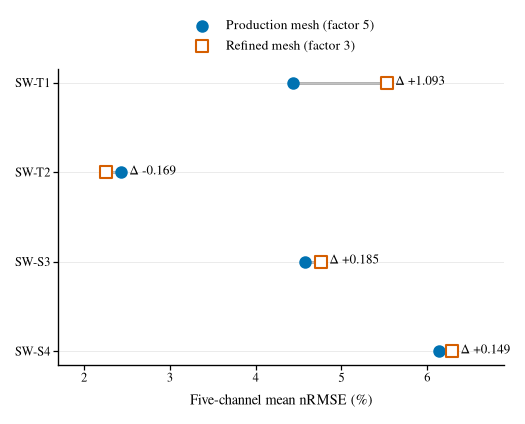

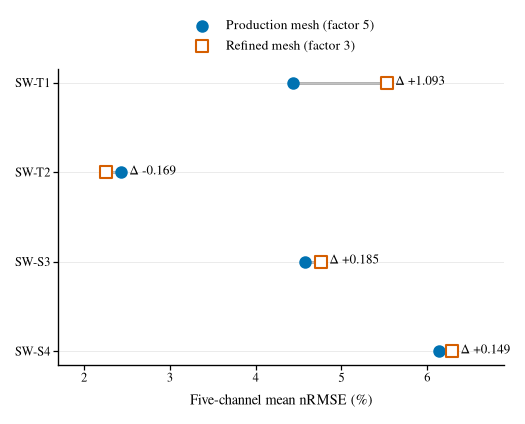

In [8]:
fig2 = paperfig.figure_mesh_sensitivity(MESH_CASES)
save_pdf('mesh_sensitivity', fig2)
display(fig2)

## 4. Figure 3 -- four-specimen validation histories

Open symbols are the eleven Table 2 observations; blue curves are the selected BBFast stage states. The gray region is unloading. The figure contains exactly the five independent scored observables.

Saved Figure_3_Validation_Histories.pdf (46.4 kB; 7.20x7.75 in, 300 dpi, Nimbus Roman)


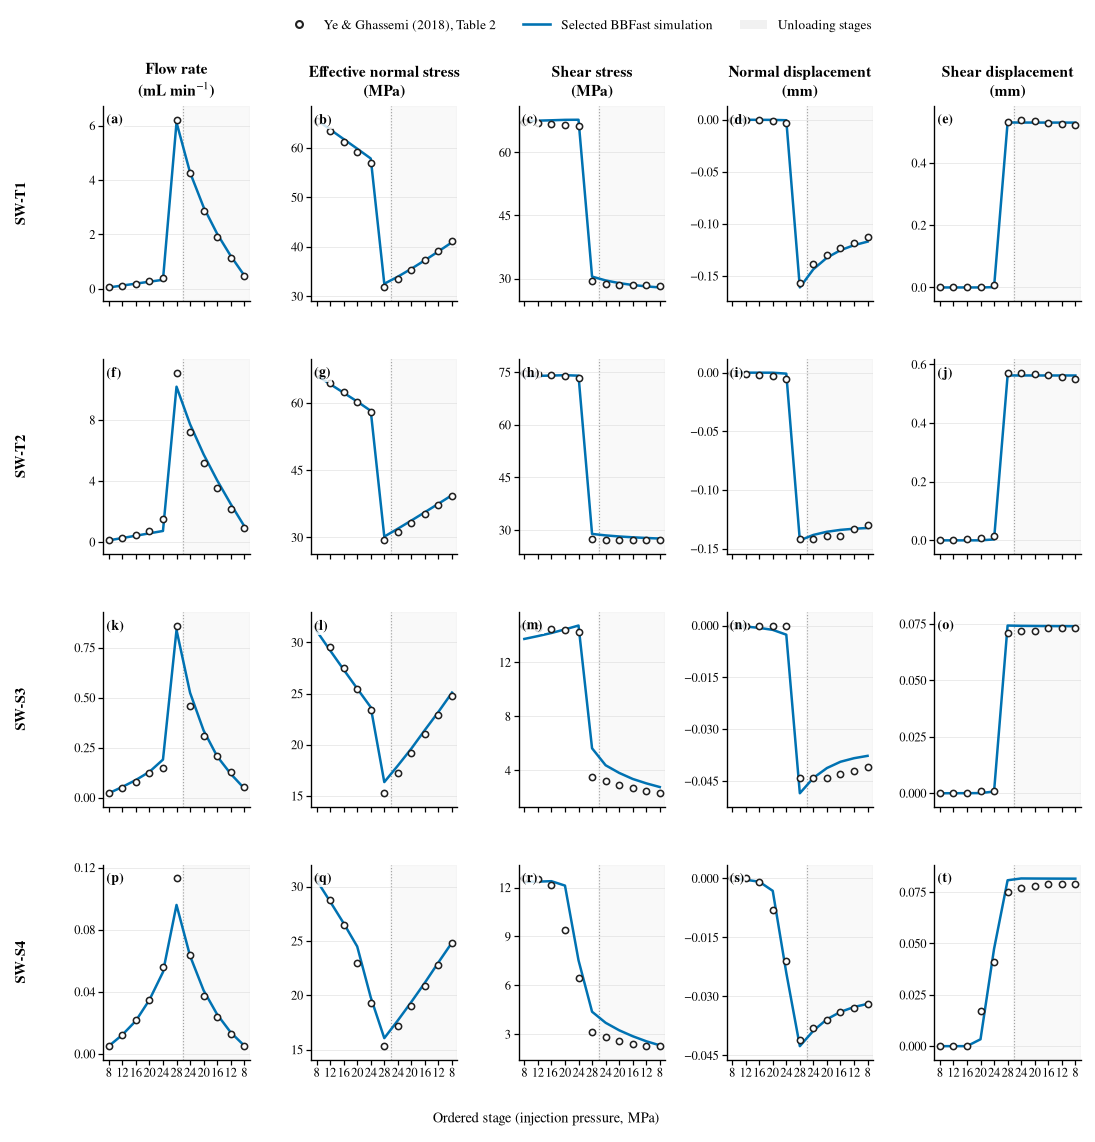

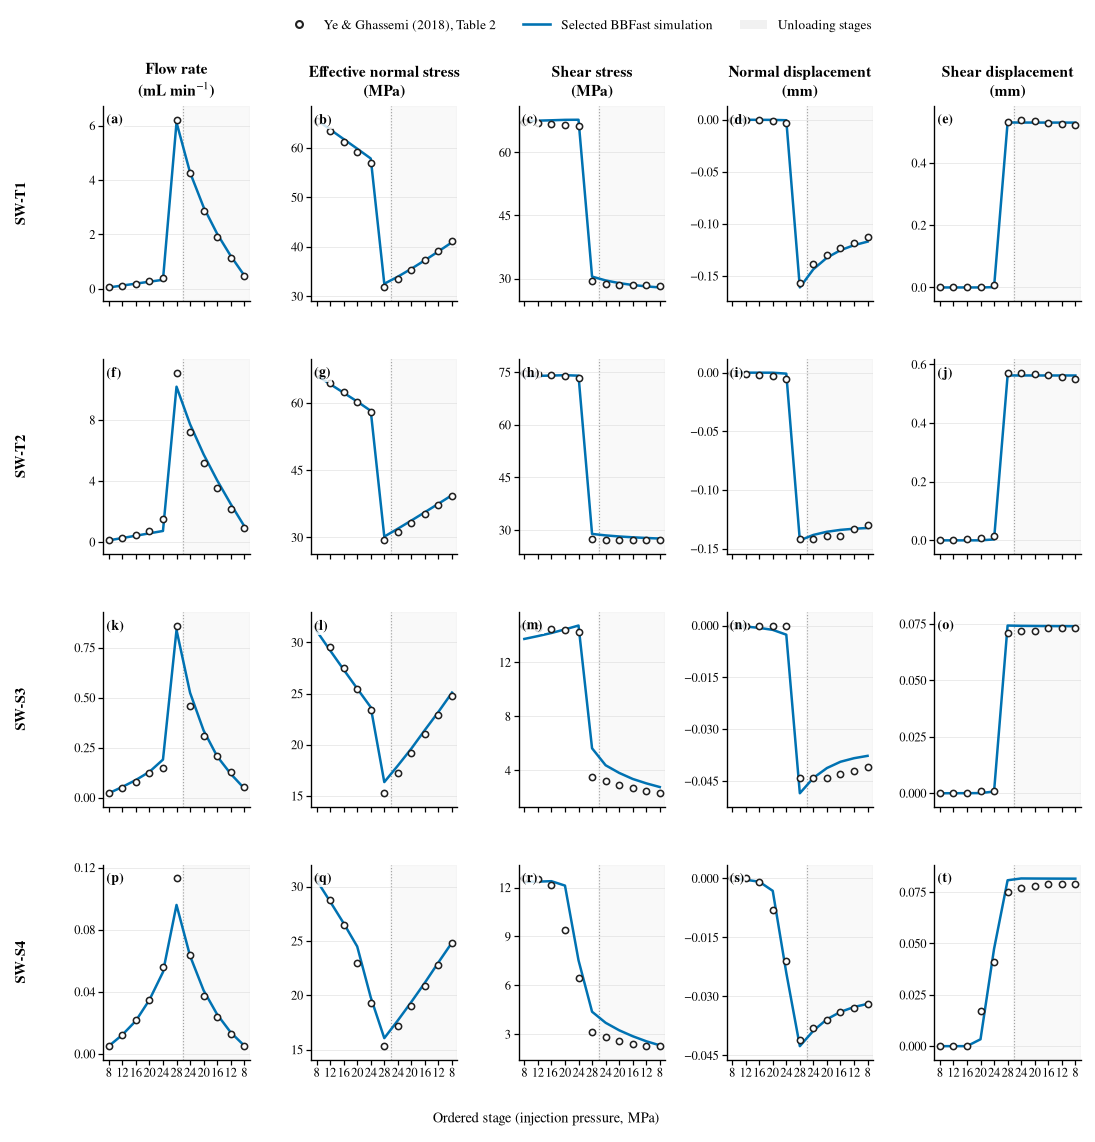

In [9]:
fig3 = paperfig.figure_validation_histories(BB_CASES)
save_pdf('validation_histories', fig3)
display(fig3)

## 5. Figure 4 -- coupled normal and hydraulic response

This shows normal displacement, hydraulic aperture, and validation-equivalent flow. The gray diamond aperture observations are explicitly labeled as derived from measured flow and are informational, not an extra validation channel.

Saved Figure_4_Hydraulic_Response.pdf (44.0 kB; 7.20x7.50 in, 300 dpi, Nimbus Roman)


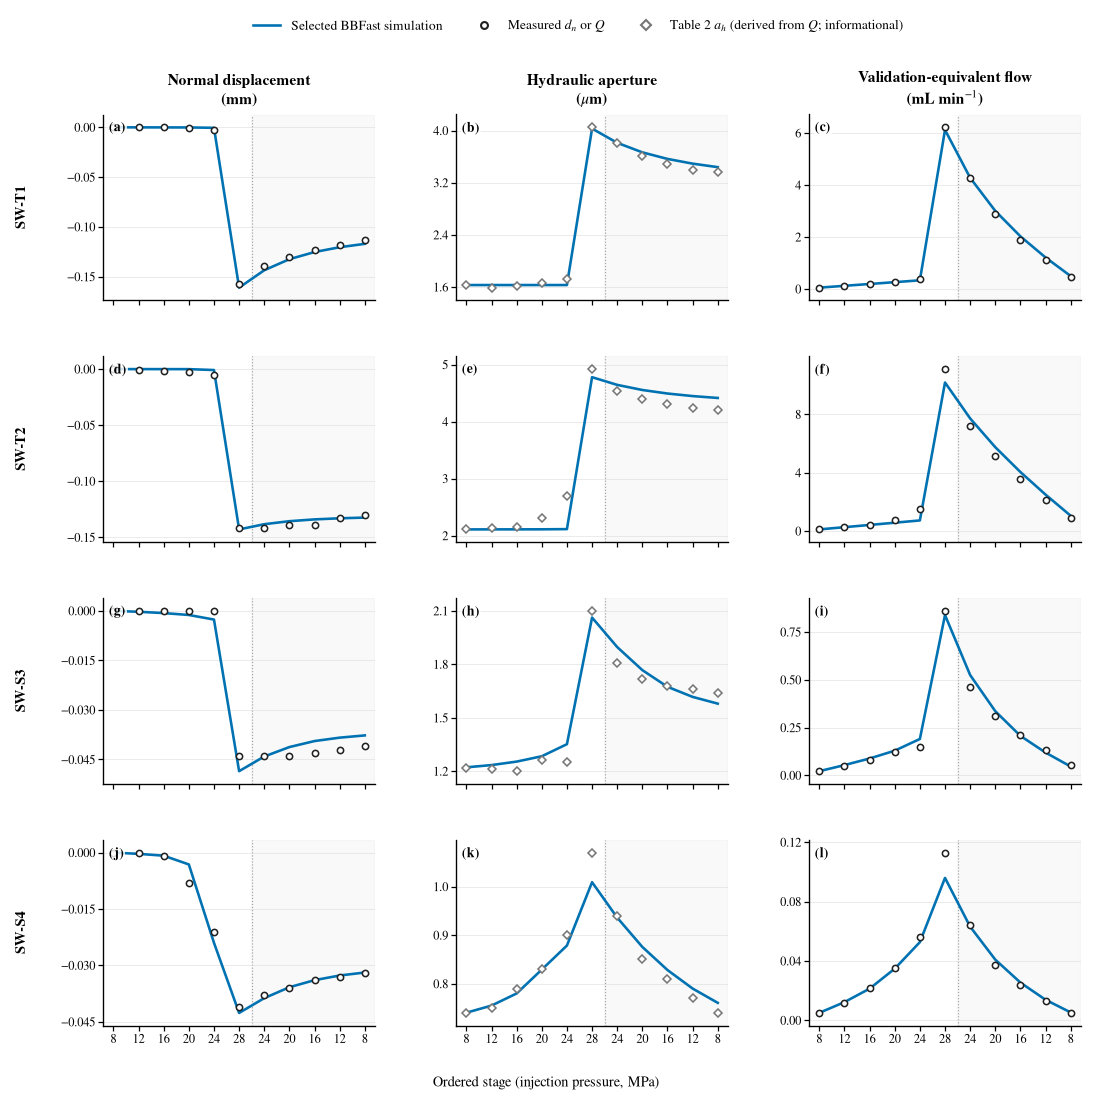

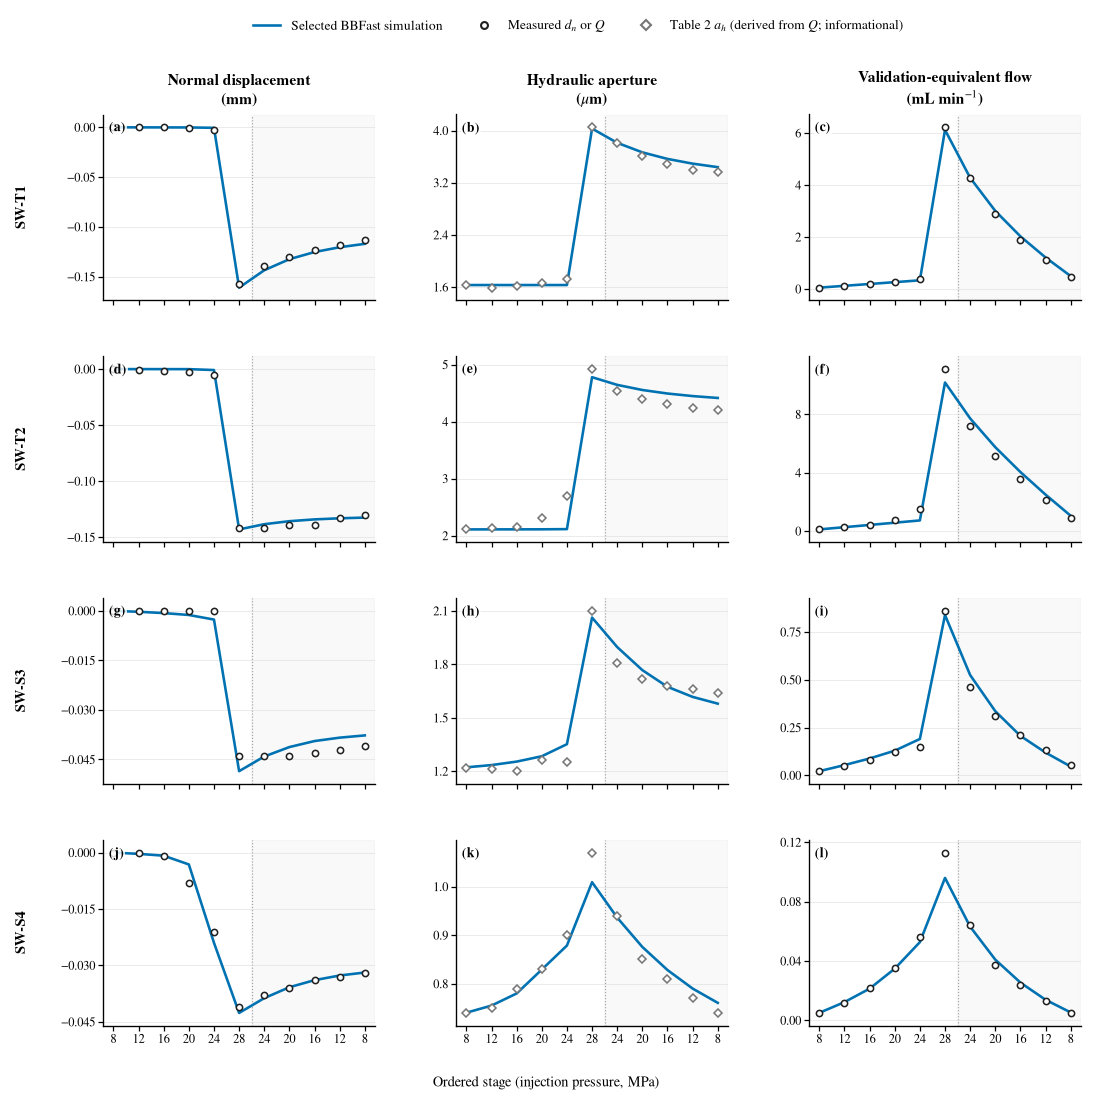

In [10]:
fig4 = paperfig.figure_hydraulic_response(BB_CASES)
save_pdf('hydraulic_response', fig4)
display(fig4)

## 6. Figure 5 -- BBFast versus Mohr--Coulomb

Shear stress and displacement expose the loading-path separation. Stage 5 is highlighted because MC weakens one stage early for SW-T1, SW-T2, and SW-S3. The final panel reports the paired five-channel mean nRMSE values.

Saved Figure_5_BBFast_vs_MC.pdf (28.7 kB; 7.20x8.45 in, 300 dpi, Nimbus Roman)


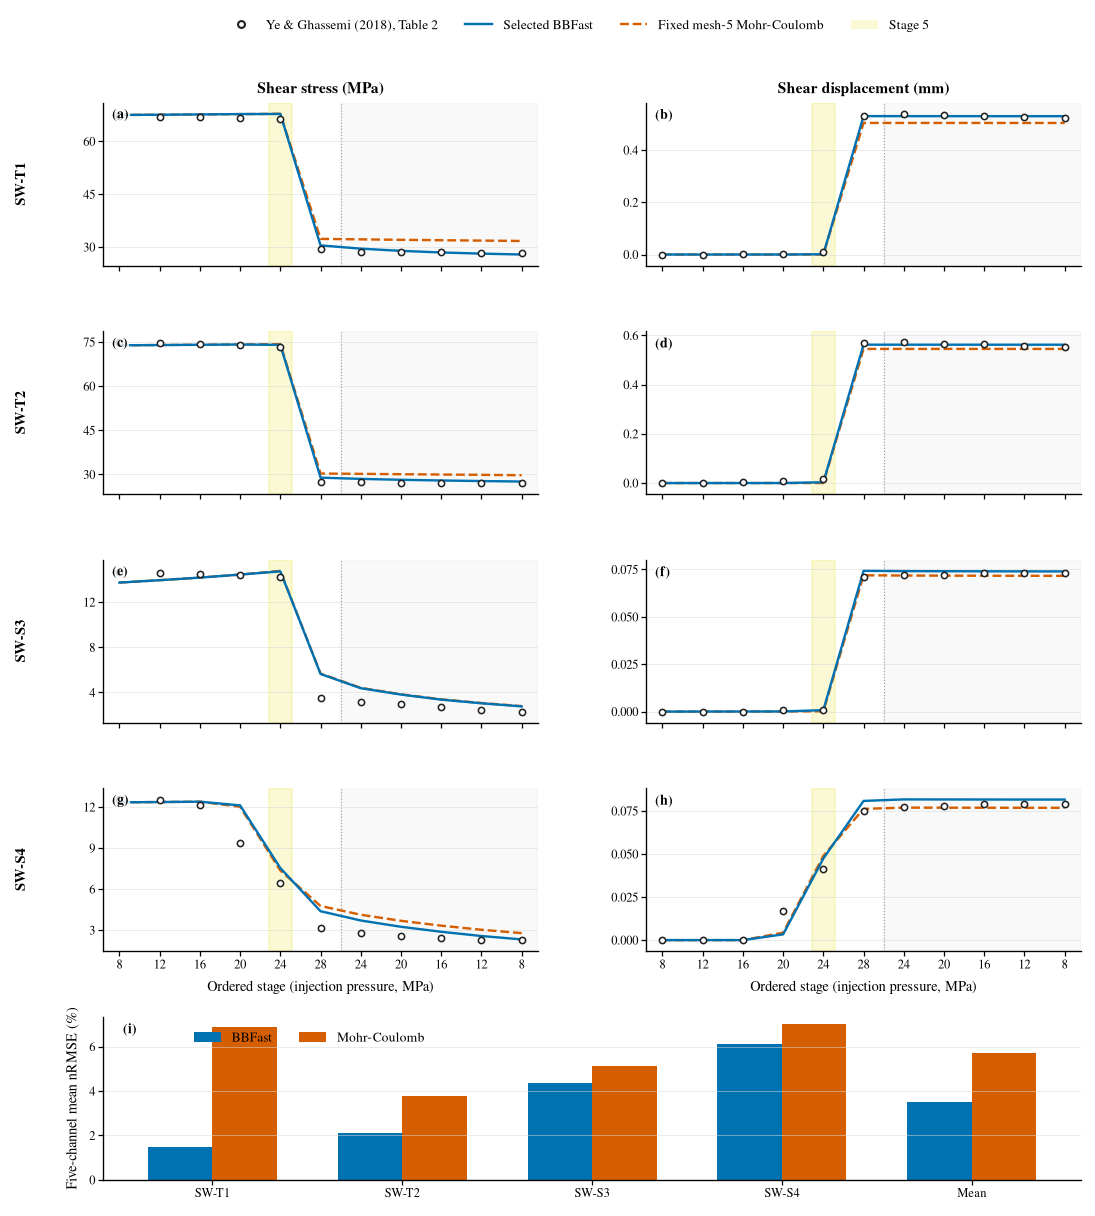

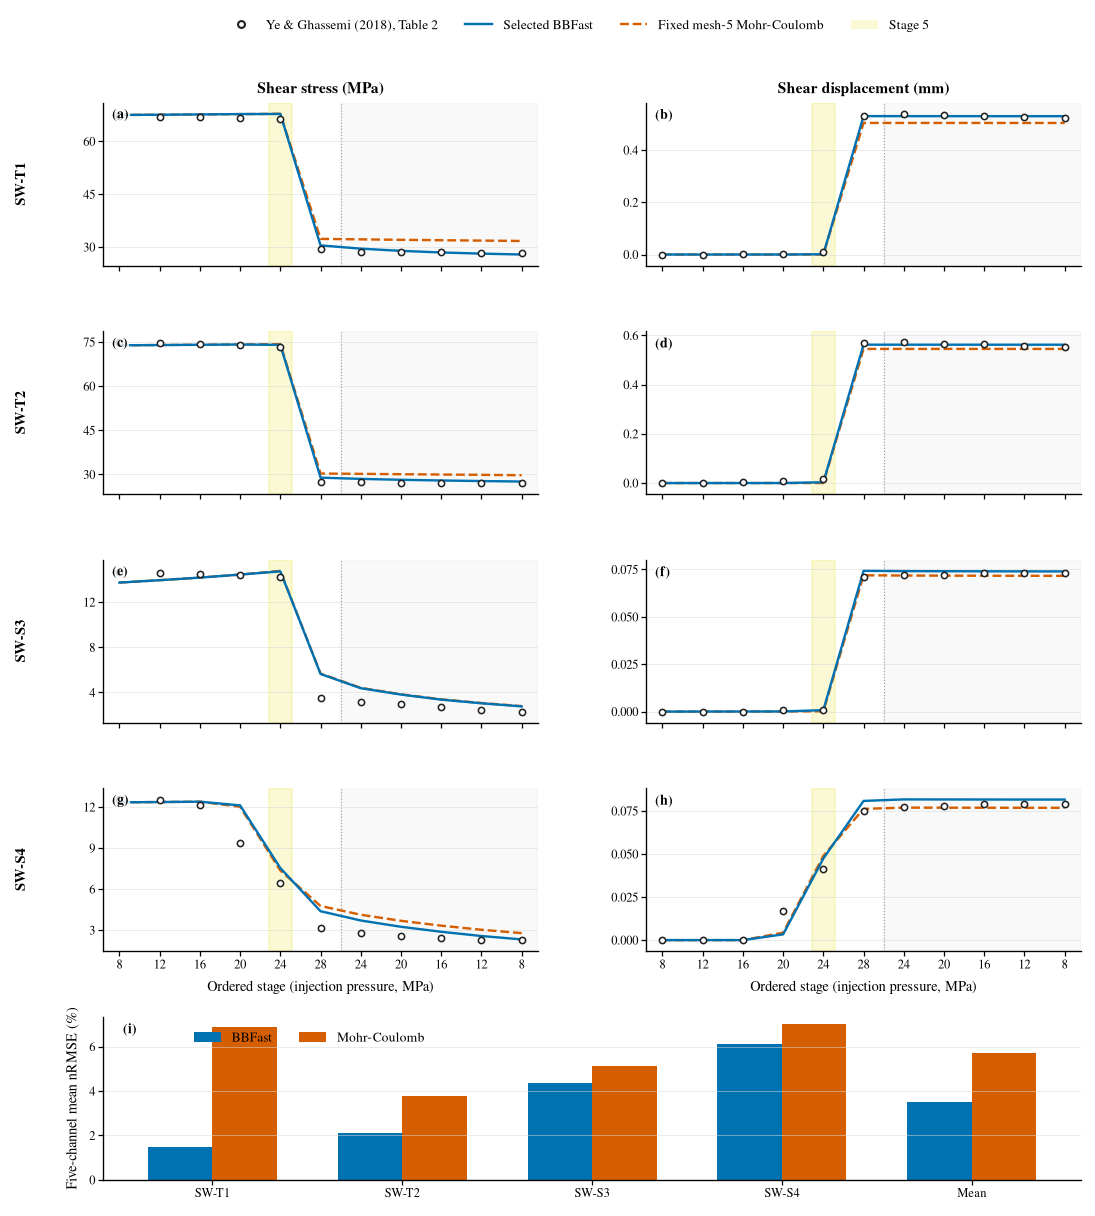

In [11]:
fig5 = paperfig.figure_bb_mc_comparison(BB_CASES, MC_CASES)
save_pdf('bb_mc_comparison', fig5)
display(fig5)

## 7. Figure 6 -- weakening-exponent controls

The full shear-displacement histories compare the BBFast parent, exponent-1 BBFast control, matched 102-series MC transfer, and experiment. The yellow band identifies stage 5.

Saved Figure_6_Weakening_Controls.pdf (21.2 kB; 7.20x2.80 in, 300 dpi, Nimbus Roman)


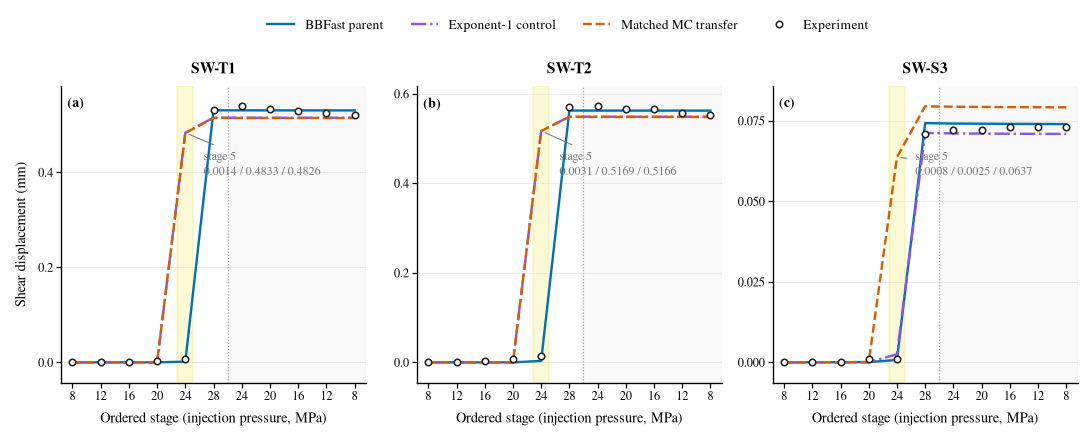

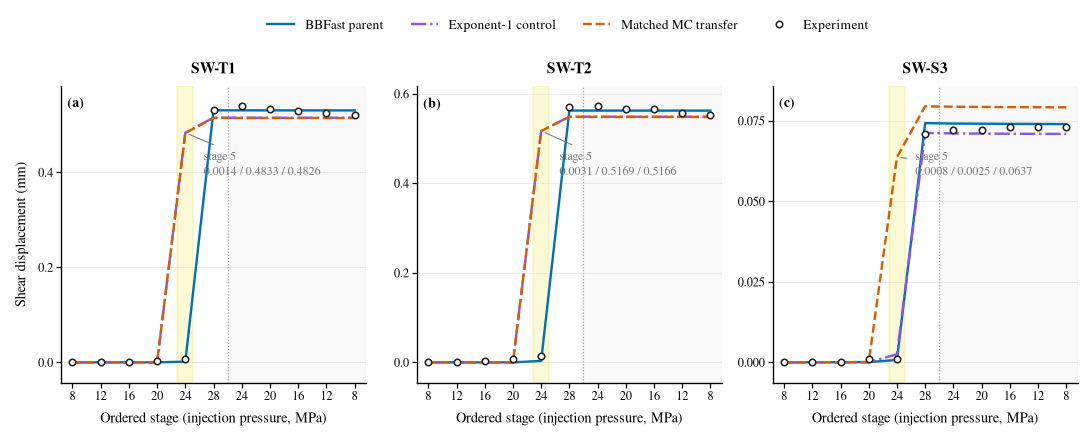

In [12]:
fig6 = paperfig.figure_weakening_controls(WEAKENING_CASES)
save_pdf('weakening_control', fig6)
display(fig6)

## 8. Export manifest and LaTeX filenames

The manuscript can replace each placeholder with `\includegraphics[width=...]` using the paths printed below. Figure 2 is intended for `\linewidth`; Figures 3--6 are intended for `\textwidth`.

In [13]:
manifest = pd.DataFrame({
    'figure': range(2, 7),
    'filename': [paperfig.FIGURE_FILENAMES[key] for key in paperfig.FIGURE_FILENAMES],
    'exists': [(OUTPUT_DIR / paperfig.FIGURE_FILENAMES[key]).is_file() for key in paperfig.FIGURE_FILENAMES],
    'size_kB': [(OUTPUT_DIR / paperfig.FIGURE_FILENAMES[key]).stat().st_size / 1024 for key in paperfig.FIGURE_FILENAMES],
})
display(manifest)

for row in manifest.itertuples(index=False):
    width = r'\linewidth' if row.figure == 2 else r'\textwidth'
    print(rf'\includegraphics[width={width}]{{Figures/{row.filename}}}')

assert manifest['exists'].all(), 'At least one manuscript PDF was not exported'

,figure,filename,exists,size_kB
0,2,Figure_2_Mesh_Sensitivity.pdf,True,18.727539
1,3,Figure_3_Validation_Histories.pdf,True,46.422852
2,4,Figure_4_Hydraulic_Response.pdf,True,44.045898
3,5,Figure_5_BBFast_vs_MC.pdf,True,28.666016
4,6,Figure_6_Weakening_Controls.pdf,True,21.179688


\includegraphics[width=\linewidth]{Figures/Figure_2_Mesh_Sensitivity.pdf}
\includegraphics[width=\textwidth]{Figures/Figure_3_Validation_Histories.pdf}
\includegraphics[width=\textwidth]{Figures/Figure_4_Hydraulic_Response.pdf}
\includegraphics[width=\textwidth]{Figures/Figure_5_BBFast_vs_MC.pdf}
\includegraphics[width=\textwidth]{Figures/Figure_6_Weakening_Controls.pdf}


### One-cell rebuild

For later reruns, the following optional cell rebuilds and saves all five PDFs in one call. It duplicates the work above, so use it instead of Sections 3--7 when you do not need inline previews.

In [14]:
# all_figures, all_manifest = paperfig.export_all(
#     OUTPUT_DIR,
#     bb_cases=BB_CASES,
#     mc_cases=MC_CASES,
#     mesh_cases=MESH_CASES,
#     weakening_cases=WEAKENING_CASES,
#     close=False,
# )
# display(all_manifest)